
[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: D:\environments\anaconda\python.exe -m pip install --upgrade pip


图片形状: torch.Size([32, 3, 32, 32])


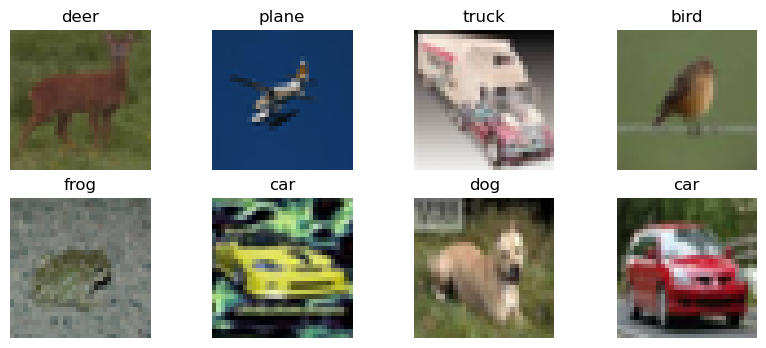

In [6]:
import sys
!{sys.executable} -m pip install tensorboard
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import numpy as np

#数据增强
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),  # 加旋转
    transforms.ColorJitter(0.2, 0.2),  # 加色彩抖动
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

#数据加载
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # 归一化到[-1,1]
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

images, labels = next(iter(trainloader))
print(f"图片形状: {images.shape}")  # [32, 3, 32, 32]

plt.figure(figsize=(10,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    img = images[i] / 2 + 0.5  # 从[-1,1]转回[0,1]
    plt.imshow(np.transpose(img.numpy(), (1,2,0)))
    plt.title(classes[labels[i]])
    plt.axis('off')
plt.show()

In [9]:
class CIFAR10CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(32, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        
        self.conv3 = nn.Conv2d(32, 32, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        
        self.conv4 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn4_conv = nn.BatchNorm2d(64)
        
        self.fc1 = nn.Linear(64 * 8 * 8, 4096)
        self.bn4_fc = nn.BatchNorm1d(4096)
        
        self.fc2 = nn.Linear(4096, 1024)
        self.fc3 = nn.Linear(1024, 256)
        self.fc4 = nn.Linear(256,10)
        
        self.drop = nn.Dropout(0.5)

    def forward(self, x):
        # 卷积块1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 32→16
        
        # 卷积块2
        x = F.relu(self.bn2(self.conv2(x)))  # 保持16
        
        # 卷积块3
        x = F.relu(self.bn3(self.conv3(x)))  # 保持16
        
        # 卷积块4 + 池化
        x = self.pool(F.relu(self.bn4_conv(self.conv4(x))))
        
        x = x.view(-1, 64 * 8 * 8)
        
        # 全连接
        x = F.relu(self.bn4_fc(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = self.fc3(x)
        x = self.drop(x)
        x = self.fc4(x)
        
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CIFAR10CNN().to(device)
print(model)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# TensorBoard
writer = SummaryWriter('runs/cifar10_experiment')


sample_images, _ = next(iter(trainloader))
writer.add_graph(model.cpu(), sample_images[:1])
model = model.to(device)

# ===== 训练 =====
epochs = 20  # CIFAR-10需要更多轮数
global_step = 0

for epoch in range(epochs):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        global_step += 1
        
        if i % 100 == 99:
            avg_loss = running_loss / 100
            writer.add_scalar('training_loss', avg_loss, global_step)
            print(f'Epoch {epoch+1}, Batch {i+1}, Loss: {avg_loss:.4f}')
            running_loss = 0.0
    
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    writer.add_scalar('test_accuracy', accuracy, epoch)
    print(f'Epoch {epoch+1} 测试准确率: {accuracy:.2f}%')
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    print(f'  学习率: {current_lr:.6f}')

writer.close()
print('训练完成！')

CIFAR10CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4_conv): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=4096, out_features=4096, bias=True)
  (bn4_fc): BatchNorm1d(4096, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=4096, out_features=1024, bias=True)
  (fc3): Line

D:\environments\anaconda\Lib\site-packages\torch\optim\lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 2, Batch 100, Loss: 1.2292
Epoch 2, Batch 200, Loss: 1.2560
Epoch 2, Batch 300, Loss: 1.2647
Epoch 2, Batch 400, Loss: 1.2065
Epoch 2, Batch 500, Loss: 1.2624
Epoch 2, Batch 600, Loss: 1.2258
Epoch 2, Batch 700, Loss: 1.2171
Epoch 2, Batch 800, Loss: 1.2079
Epoch 2, Batch 900, Loss: 1.2085
Epoch 2, Batch 1000, Loss: 1.2405
Epoch 2, Batch 1100, Loss: 1.2391
Epoch 2, Batch 1200, Loss: 1.1864
Epoch 2, Batch 1300, Loss: 1.1402
Epoch 2, Batch 1400, Loss: 1.2105
Epoch 2, Batch 1500, Loss: 1.1258
Epoch 2 测试准确率: 60.94%
  学习率: 0.001000
Epoch 3, Batch 100, Loss: 1.0654
Epoch 3, Batch 200, Loss: 1.0888
Epoch 3, Batch 300, Loss: 1.0885
Epoch 3, Batch 400, Loss: 1.0883
Epoch 3, Batch 500, Loss: 1.0954
Epoch 3, Batch 600, Loss: 1.0887
Epoch 3, Batch 700, Loss: 1.0479
Epoch 3, Batch 800, Loss: 1.1039
Epoch 3, Batch 900, Loss: 1.0856
Epoch 3, Batch 1000, Loss: 1.1025
Epoch 3, Batch 1100, Loss: 1.0435
Epoch 3, Batch 1200, Loss: 1.0471
Epoch 3, Batch 1300, Loss: 1.0449
Epoch 3, Batch 1400, Loss: 1

In [10]:
torch.save(model.state_dict(), 'cifar10_75.pth')
writer = SummaryWriter('runs/mnist_final')